<a href="https://colab.research.google.com/github/daviseemann/turbofan-rul-prediction-cmapss/blob/production/notebooks/MLP-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount(
    "/content/drive/",
)
import os

os.chdir(
    "/content/drive/MyDrive/Data science studies/Aprendizado-de-maquina-UFSC/final-project/data"
)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [62]:
# Caminhos dos arquivos
train_path = "./6.turbofan rul/train_FD001.txt"
test_path = "./6.turbofan rul/test_FD001.txt"
rul_path = "./6.turbofan rul/RUL_FD001.txt"

# Nomes das colunas (de acordo com a documentação original do C-MAPSS)
column_names = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1, 4)]
    + [f"s{i}" for i in range(1, 22)]
)

# Importando os arquivos (espaço em branco como delimitador)
df_train_raw = pd.read_csv(train_path, sep="\s+", header=None, names=column_names)
df_test = pd.read_csv(test_path, sep="\s+", header=None, names=column_names)
df_rul = pd.read_csv(rul_path, sep="\s+", header=None, names=["RUL"])

In [63]:
display(df_train_raw.head())
display(df_test.head())
display(df_rul.head())

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


,RUL
0,112
1,98
2,69
3,82
4,91


# Pré-processamento


### Seleção de Sensores

O artigo menciona que apenas 14 dos 21 sensores são usados. Vamos selecionar os mesmos:


In [64]:
# Sensores selecionados conforme o artigo
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s8",
    "s9",
    "s11",
    "s12",
    "s13",
    "s14",
    "s15",
    "s17",
    "s20",
    "s21",
]

# Colunas que vamos manter
features_to_keep = ["engine_id", "cycle"] + selected_sensors

# Filtrando os dataframes
df_train_raw = df_train_raw[features_to_keep]
df_test = df_test[features_to_keep]

### Normalização dos Dados

O artigo usa normalização min-max para o intervalo [-1, 1]:


In [65]:
from sklearn.preprocessing import MinMaxScaler

# def min_max_normalize(train_df, test_df, features):
#     """Normaliza as features para o intervalo [-1, 1] sem data leakage"""
#     scaler = MinMaxScaler(feature_range=(-1, 1))
#     scaler.fit(train_df[features])  # Ajusta apenas no treino

#     # Aplica a transformação no treino e no teste
#     train_df[features] = scaler.transform(train_df[features])
#     test_df[features] = scaler.transform(test_df[features])

#     return train_df, test_df, scaler

# # Normalizando os dados
# features_to_normalize = selected_sensors
# df_train_raw, df_test, scaler = min_max_normalize(df_train_raw, df_test, features_to_normalize)

### Criando os RULs para Treino

O artigo usa um modelo de degradação linear por partes com RUL constante inicial (Re):


In [66]:
def create_rul_labels(df, Re, clip_at_zero=True):
    """Cria os rótulos RUL usando o modelo de degradação linear por partes"""
    grouped = df.groupby("engine_id")["cycle"].max().reset_index()
    grouped.columns = ["engine_id", "max_cycle"]

    df = df.merge(grouped, on="engine_id", how="left")
    df["RUL"] = df["max_cycle"] - df["cycle"]

    # Aplica o modelo de degradação linear por partes
    df["RUL"] = np.where(df["RUL"] > Re, Re, df["RUL"])

    return df.drop(columns=["max_cycle"])

# Usando Re=128 conforme sugerido no artigo para FD001
Re = 128
df_train_raw = create_rul_labels(df_train_raw, Re)

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rul_by_engine(df, engines_to_plot=5):
    """Plota o RUL ao longo do tempo para algumas engines"""
    # Selecionar engines para visualizar
    engine_ids = df["engine_id"].unique()[:engines_to_plot]

    plt.figure(figsize=(8, 6))

    for engine_id in engine_ids:
        engine_data = df[df["engine_id"] == engine_id]
        plt.plot(engine_data["cycle"], engine_data["RUL"], label=f'Engine {engine_id}')

    plt.xlabel('Cycle')
    plt.ylabel('RUL')
    plt.title('RUL por Engine ID')
    plt.legend()
    plt.grid(True)
    plt.show()


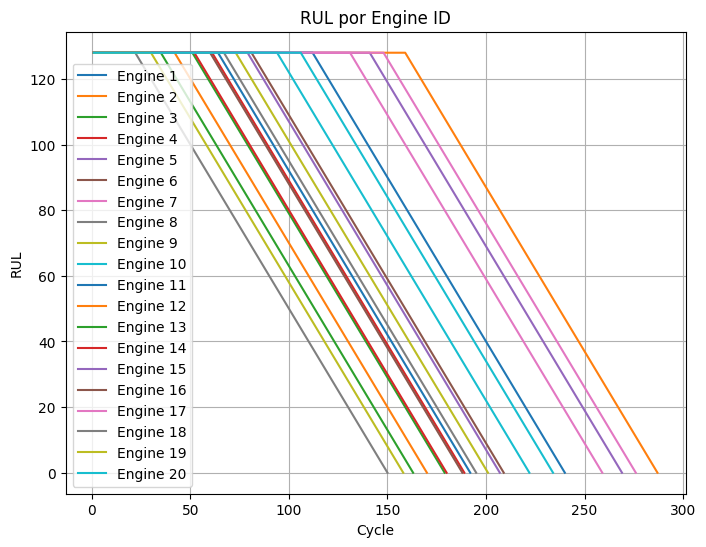

In [68]:
plot_rul_by_engine(df_train_raw, engines_to_plot=20)

### Preparando as Janelas Temporais

O artigo usa janelas temporais com tamanho (nw) e stride (ns):


separando os dados de validação e treino

In [69]:
from sklearn.model_selection import train_test_split

unique_engines = np.unique(df_train_raw['engine_id'])
train_engines, val_engines = train_test_split(unique_engines, test_size=0.2, shuffle=False)

df_train = df_train_raw[df_train_raw['engine_id'].isin(train_engines)]
df_val = df_train_raw[df_train_raw['engine_id'].isin(val_engines)]
display(train_engines, df_train.shape)
display(val_engines, df_val.shape)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])

(16138, 17)

array([ 81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100])

(4493, 17)

In [70]:
def create_time_windows(df, window_size, window_stride, sensor_cols):
    """Cria janelas temporais dos dados dos sensores e retorna um DataFrame com info da janela"""
    sequences = []
    labels = []
    engine_ids = []
    last_cycles = []

    for engine_id in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == engine_id]
        sensor_data = engine_data[sensor_cols].values
        rul_data = engine_data["RUL"].values

        # Cria janelas deslizantes
        for i in range(0, len(engine_data) - window_size + 1, window_stride):
            window = sensor_data[i: i + window_size]
            label = rul_data[i + window_size - 1]
            sequences.append(window)
            labels.append(label)
            engine_ids.append(engine_id)
            last_cycles.append(engine_data["cycle"].iloc[i + window_size - 1])

    # Flatten sequences for MLP input
    n_samples = len(sequences)
    n_timesteps = window_size
    n_features = len(sensor_cols)
    flattened_sequences = np.array(sequences).reshape((n_samples, n_timesteps * n_features))

    df_windows = pd.DataFrame({
        'engine_id': engine_ids,
        'last_cycle': last_cycles,
        'data_vector': list(flattened_sequences),
        'RUL': labels
    })

    return df_windows

# Parâmetros do artigo para FD001: nw=24, ns=1
window_size = 24
window_stride = 1

# Criando as sequências de treino
sensor_cols = selected_sensors
df_train_windows = create_time_windows(df_train, window_size, window_stride, sensor_cols)

# Criando as sequências de validação
df_val_windows = create_time_windows(df_val, window_size, window_stride, sensor_cols)

# Separando X_train e y_train
X_train = np.array(list(df_train_windows['data_vector']))
y_train = df_train_windows['RUL'].values
display(df_train_windows.head())

# Separando X_val e y_val
X_val = np.array(list(df_val_windows['data_vector']))
y_val = df_val_windows['RUL'].values
val_data= (X_val, y_val)
display(df_val_windows.head())

,engine_id,last_cycle,data_vector,RUL
0,1,24,"[641.82, 1589.7, 1400.6, 554.36, 2388.06, 9046...",128
1,1,25,"[642.15, 1591.82, 1403.14, 553.75, 2388.04, 90...",128
2,1,26,"[642.35, 1587.99, 1404.2, 554.26, 2388.08, 905...",128
3,1,27,"[642.35, 1582.79, 1401.87, 554.45, 2388.11, 90...",128
4,1,28,"[642.37, 1582.85, 1406.22, 554.0, 2388.06, 905...",128


,engine_id,last_cycle,data_vector,RUL
0,81,24,"[642.04, 1589.91, 1406.63, 553.78, 2388.1, 906...",128
1,81,25,"[642.65, 1586.25, 1407.88, 553.7, 2388.09, 906...",128
2,81,26,"[642.55, 1586.42, 1396.4, 553.28, 2388.11, 905...",128
3,81,27,"[642.41, 1594.89, 1404.86, 554.25, 2388.04, 90...",128
4,81,28,"[643.41, 1590.49, 1409.58, 553.5, 2388.04, 905...",128


# Arquitetura da MLP

In [71]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer


def root_mean_squared_error(y_true, y_pred):
    # Converte os inputs para float32 explicitamente
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    squared_diff = tf.square(y_pred - y_true)
    mean_squared = tf.reduce_mean(squared_diff)
    rmse = tf.sqrt(mean_squared)
    return rmse


def rul_health_score(y_true, y_pred):
    # 1) Garante vetores 1D float32
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    d = y_pred - y_true

    score = tf.where(
        d < 0.0,
        tf.exp(-d / 13.0) - 1.0,
        tf.exp(d / 10.0) - 1.0
    )

    return tf.reduce_mean(score)


class MinMaxScalerLayer(Layer):
    def __init__(self, mins, denom, **kwargs):
        super().__init__(**kwargs)
        self.mins  = tf.constant(mins)
        self.denom = tf.constant(denom)

    def call(self, inputs):
        return 2.0 * (inputs - self.mins) / self.denom - 1.0

In [72]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.metrics import MeanSquaredError, RootMeanSquaredError

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1_l2

def create_mlp(input_dim, minmax_layer, lr=0.001, l1=0.1, l2=0.2):
    reg = l1_l2(l1=l1, l2=l2)

    model = Sequential(
        [
            Input(shape=(input_dim,)),
            minmax_layer,                           # <-- usa a camada, não chama
            Dense(20, activation="relu",
                  kernel_regularizer=reg, bias_regularizer=reg),
            Dense(20, activation="relu",
                  kernel_regularizer=reg, bias_regularizer=reg),
            Dense(1, activation="linear",
                  kernel_regularizer=reg, bias_regularizer=reg),
        ],
        name="Arquitetura-1",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[
            MeanSquaredError(name="mse"),
            RootMeanSquaredError(name="rmse"),
            rul_health_score,
        ],
    )
    return model



In [73]:
# Criando o pre-processamento
mins  = X_train.min(axis=0).astype("float32")
maxs  = X_train.max(axis=0).astype("float32")
denom = maxs - mins
minmax_layer = MinMaxScalerLayer(mins, denom, name="minmax_-1_1")


# Criando o modelo
input_dim = X_train.shape[1]
model = create_mlp(input_dim=X_train.shape[1],
                   minmax_layer=minmax_layer)
model.summary()

Model: "Arquitetura-1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ minmax_-1_1 (MinMaxScalerLayer) │ (None, 336)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │         6,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,181 (28.05 KB)

 Trainable params: 7,181 (28.05 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history = model.fit(
    X_train, y_train,
    validation_data=val_data,
    epochs=100,
    batch_size=128,
    verbose=2
)

Epoch 1/100
112/112 - 6s - 51ms/step - loss: 5522.3608 - mse: 5452.9707 - rmse: 73.8442 - rul_health_score: 2466.2380 - val_loss: 1585.9521 - val_mse: 1499.3392 - val_rmse: 38.7213 - val_rul_health_score: 79.2917
Epoch 2/100
112/112 - 0s - 3ms/step - loss: 879.1488 - mse: 793.4003 - rmse: 28.1674 - rul_health_score: 22.6270 - val_loss: 626.2024 - val_mse: 543.2423 - val_rmse: 23.3076 - val_rul_health_score: 10.7242
Epoch 3/100
112/112 - 0s - 3ms/step - loss: 520.3877 - mse: 437.0956 - rmse: 20.9068 - rul_health_score: 8.6423 - val_loss: 520.5140 - val_mse: 435.5329 - val_rmse: 20.8694 - val_rul_health_score: 9.2413
Epoch 4/100
112/112 - 0s - 3ms/step - loss: 452.2518 - mse: 365.8946 - rmse: 19.1284 - rul_health_score: 7.4726 - val_loss: 476.6367 - val_mse: 388.7926 - val_rmse: 19.7178 - val_rul_health_score: 7.7646
Epoch 5/100
112/112 - 0s - 3ms/step - loss: 416.7110 - mse: 327.6382 - rmse: 18.1008 - rul_health_score: 6.4955 - val_loss: 445.3576 - val_mse: 355.2247 - val_rmse: 18.8474 

In [75]:
history.history.keys()

dict_keys(['loss', 'mse', 'rmse', 'rul_health_score', 'val_loss', 'val_mse', 'val_rmse', 'val_rul_health_score'])

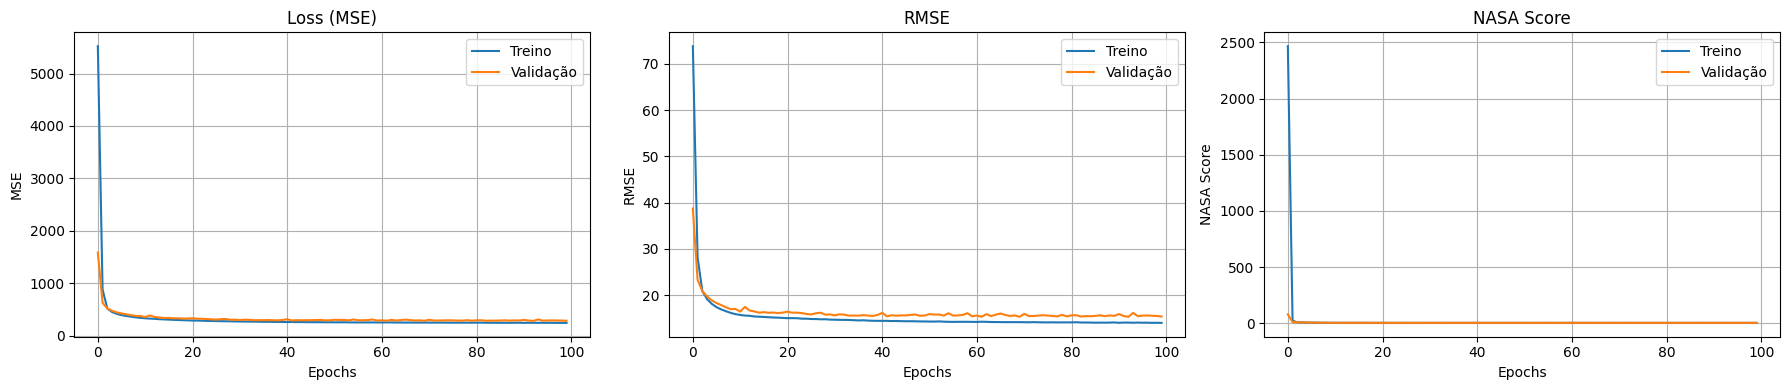

In [76]:
def plot_learning_curves(history):

    plt.figure(figsize=(18, 4))

    # Plot Loss (MSE)
    plt.subplot(1, 3, 1)
    plt.plot(history.history["loss"], label="Treino")
    plt.plot(history.history["val_loss"], label="Validação")
    plt.title("Loss (MSE)")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)

    # Plot RMSE
    if "rmse" in history.history:
        plt.subplot(1, 3, 2)
        plt.plot(history.history["rmse"], label="Treino")
        plt.plot(history.history["val_rmse"], label="Validação")
        plt.title("RMSE")
        plt.xlabel("Epochs")
        plt.ylabel("RMSE")
        plt.legend()
        plt.grid(True)

    # Plot NASA Score
    if "rul_health_score" in history.history:
        plt.subplot(1, 3, 3)
        plt.plot(history.history["rul_health_score"], label="Treino")
        plt.plot(history.history["val_rul_health_score"], label="Validação")
        plt.title("NASA Score")
        plt.xlabel("Epochs")
        plt.ylabel("NASA Score")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()

    plt.show()

plot_learning_curves(history)

In [77]:
def rul_health_score_manual(y_true, y_pred):
    # Ensure inputs are numpy arrays and of float type
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    diffs = y_pred - y_true
    scores = np.where(diffs < 0, np.exp(- diffs / 13.0) - 1.0, np.exp(diffs / 10.0) - 1.0)
    return np.mean(scores)

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


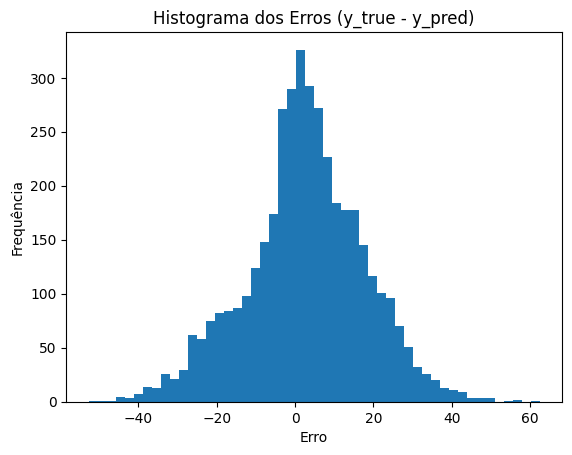

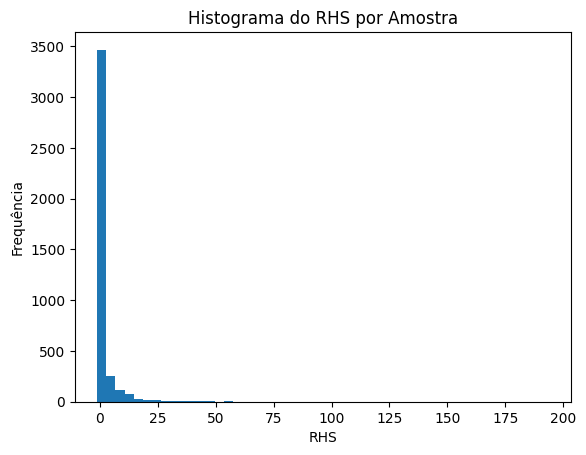

RHS (Val Set): 3.58


In [78]:
import matplotlib.pyplot as plt

# Previsões e erros
y_pred_val = model.predict(X_val).flatten()
errors = y_val - y_pred_val

# Histograma dos erros
plt.figure()
plt.hist(errors, bins=50)
plt.title('Histograma dos Erros (y_true - y_pred)')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.show()

# Calcula o RHS por amostra seguindo o paper
d = y_pred_val - y_val
rhs_samples = np.where(
    d < 0,
    np.exp(d / 13.0) - 1.0,   # under-prediction
    np.exp(d / 10.0) - 1.0    # over-prediction
)

# Plota histograma do RHS por amostra
plt.figure()
plt.hist(rhs_samples, bins=50)
plt.title('Histograma do RHS por Amostra')
plt.xlabel('RHS')
plt.ylabel('Frequência')
plt.show()

# Cálculo manual do RHS
rhs_val = rul_health_score_manual(y_val, y_pred_val)
print(f'RHS (Val Set): {rhs_val:.2f}')


In [79]:
def plot_rul_predictions(df, start=1,stop=1, dataset_type='train'):
    """
    Plota a comparação entre RUL real e RUL predito por engine_id.

    Parâmetros:
    - df: DataFrame contendo as colunas ['engine_id', 'cycle', 'RUL', 'RUL_PREDICTED']
    - engines_to_plot: Quantidade de engines a serem exibidas
    - dataset_type: 'train' ou 'test' (apenas para título)
    """
    engine_ids = df["engine_id"].unique()[start-1:stop]

    plt.figure(figsize=(5, 4))

    for engine_id in engine_ids:
        engine_data = df[df["engine_id"] == engine_id]
        plt.plot(engine_data["last_cycle"], engine_data["RUL"], label=f'Engine {engine_id} - Real', linestyle='-')
        plt.plot(engine_data["last_cycle"], engine_data["RUL_PREDICTED"], label=f'Engine {engine_id} - Predicted', linestyle='--')

    plt.xlabel('last_cycle')
    plt.ylabel('RUL')
    plt.title(f'Comparação RUL Real vs. Predito ({dataset_type.capitalize()} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_prediction(df, engine_id= 1, dataset_type='train'):

    plt.figure(figsize=(5, 4))

    engine_data = df[df["engine_id"] == engine_id]
    plt.plot(engine_data["last_cycle"], engine_data["RUL"], label=f'Engine {engine_id} - Real', linestyle='-')
    plt.plot(engine_data["last_cycle"], engine_data["RUL_PREDICTED"], label=f'Engine {engine_id} - Predicted', linestyle='--')

    plt.xlabel('last_cycle')
    plt.ylabel('RUL')
    plt.title(f'Comparação RUL Real vs. Predito ({dataset_type.capitalize()} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


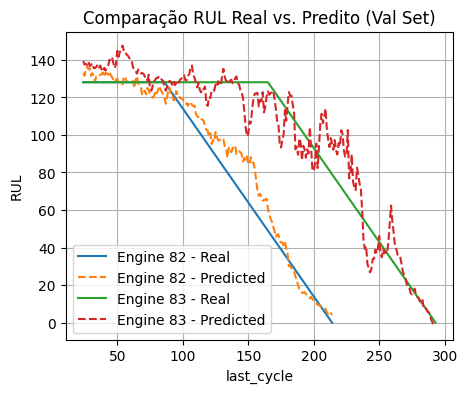

In [80]:
df_val_windows = df_val_windows.reset_index(drop=True)

# Criando o DataFrame de resultados
df_results = df_val_windows[["engine_id", "RUL", "last_cycle"]].copy()

df_results['RUL_PREDICTED'] = model.predict(X_val)

plot_rul_predictions(df_results, start=2,stop=3,dataset_type='val')
# plot_prediction(df=df_results, engine_id=1, dataset_type='val')

# Avaliando no conjunto de teste

In [81]:
df_rul['engine_id'] = df_rul.index + 1
display(df_rul.head())

,RUL,engine_id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


### preparando os dados de teste

In [82]:
import numpy as np

# Parâmetros
window_size = 24
sensor_cols  = selected_sensors

# Supondo que df_rul tenha colunas ['engine_id', 'RUL']
df_rul = df_rul.rename(columns={'RUL':'true_RUL'})

# Geração das janelas e labels
X_test = []
y_test = []

for eid, group in df_test.groupby('engine_id', sort=False):
    data = group[sensor_cols].values
    # Pega só a última janela completa
    window = data[-window_size:]
    X_test.append(window.flatten())
    # Usa o RUL “verdadeiro” do df_rul
    y_test.append(
        df_rul.loc[df_rul['engine_id']==eid, 'true_RUL'].item()
    )

# Converte para arrays
X_test = np.stack(X_test)   # shape (n_engines, window_size * n_sensores)
y_test = np.array(y_test)   # shape (n_engines,)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
RHS médio (Test Set): 3.63


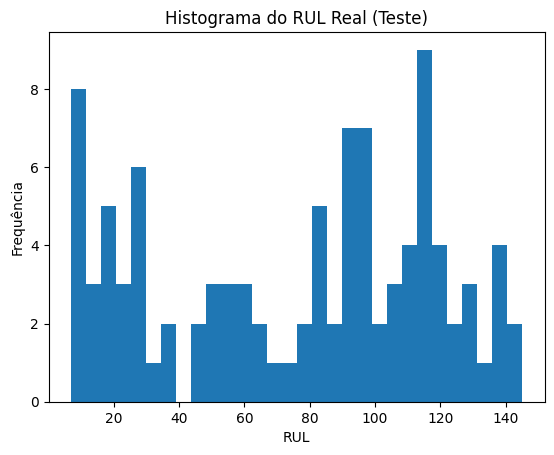

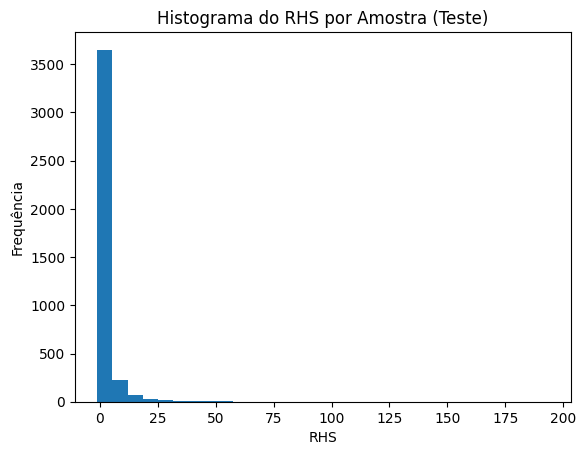

In [83]:
# 3.1 – Predição
y_pred_test = model.predict(X_test).flatten()

# 3.2 – RHS por amostra (mesma fórmula do paper)
rhs_mean_test = rul_health_score_manual(y_test, y_pred_test)

# 3.3 – Impressão e histogramas
print(f'RHS médio (Test Set): {rhs_mean_test:.2f}')

import matplotlib.pyplot as plt

plt.figure()
plt.hist(y_test, bins=30)
plt.title('Histograma do RUL Real (Teste)')
plt.xlabel('RUL')
plt.ylabel('Frequência')
plt.show()

plt.figure()
plt.hist(rhs_samples, bins=30)
plt.title('Histograma do RHS por Amostra (Teste)')
plt.xlabel('RHS')
plt.ylabel('Frequência')
plt.show()


,Artigo,Meu Modelo
Métrica,,
RHS (Test Set),5.98,3.632055
RMSE (Test Set),16.22,14.488377


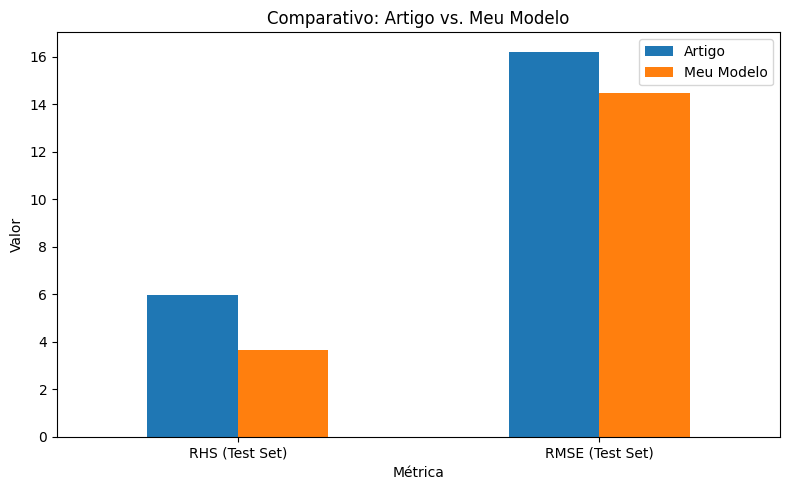

In [84]:
# 1) Defina aqui os valores reportados no artigo
article_metrics = {
    'RHS (Test Set)': 5.98,
    'RMSE (Test Set)': 16.22
}

# 2) Defina aqui os valores que você obteve
my_metrics = {
    'RHS (Test Set)': rhs_mean_test,
    'RMSE (Test Set)': float(root_mean_squared_error(y_test, y_pred_test))
}

# 3) Monte o DataFrame comparativo
df_cmp = pd.DataFrame({
    'Artigo': article_metrics,
    'Meu Modelo': my_metrics
})
df_cmp.index.name = 'Métrica'
display(df_cmp)

# 4) Plot de barras
ax = df_cmp.plot.bar(rot=0, figsize=(8,5))
ax.set_ylabel('Valor')
ax.set_title('Comparativo: Artigo vs. Meu Modelo')
plt.tight_layout()
plt.show()


In [85]:
# Salvando o modelo

save_dir = './turbofan_artifacts/architecture_1'
os.makedirs(save_dir, exist_ok=True)
print('Salvando artefatos em:', save_dir)

Salvando artefatos em: ./turbofan_artifacts/architecture_1


In [86]:
model.summary()
model_path = os.path.join(save_dir, 'turbofan_mlp_model.keras')
model.save(model_path)
print('Modelo salvo em:', model_path)


Model: "Arquitetura-1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ minmax_-1_1 (MinMaxScalerLayer) │ (None, 336)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │         6,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,545 (84.16 KB)

 Trainable params: 7,181 (28.05 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,364 (56.11 KB)

NotImplementedError: 
Object MinMaxScalerLayer was created by passing
non-serializable argument values in `__init__()`,
and therefore the object must override `get_config()` in
order to be serializable. Please implement `get_config()`.

Example:

class CustomLayer(keras.layers.Layer):
    def __init__(self, arg1, arg2, **kwargs):
        super().__init__(**kwargs)
        self.arg1 = arg1
        self.arg2 = arg2

    def get_config(self):
        config = super().get_config()
        config.update({
            "arg1": self.arg1,
            "arg2": self.arg2,
        })
        return config

In [ ]:
import json

history_path = os.path.join(save_dir, 'history.json')
with open(history_path, 'w') as f:
    json.dump(history.history, f, indent=2)
print('History salvo em:', history_path)


In [ ]:
csv_path = os.path.join(save_dir, 'metrics.csv')
df_cmp.to_csv(csv_path)

print('Métricas salvas em:', csv_path)

In [ ]:
!pwd

In [ ]:
# Check the contents of the save directory
!ls -lR {save_dir}

## Otimização dos hiperparametros

In [ ]:
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='loss',      # ou 'val_rmse'
    factor=0.1,          # LR ← LR * 0.5
    patience=10,          # espera 5 epochs sem melhora
    min_lr=1e-6,
    verbose=1
)

In [ ]:
from itertools import product
import pandas as pd
import tensorflow as tf
import logging

# 1) Função de treino que usa model.evaluate
def train_and_eval(X_train, y_train, X_test, y_test, lr, l1, l2):
    input_dim = X_train.shape[1]
    model = create_mlp(input_dim=input_dim, lr=lr, l1=l1, l2=l2)

    reduce_lr = ReduceLROnPlateau(monitor='loss', patience=10, factor=0.5, min_lr=1e-6, verbose=0)

    print(f'Treinando com lr={lr}, l1={l1}, l2={l2}')
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=128,
        verbose=0,
        callbacks=[reduce_lr]
    )

    y_test_pred = model.predict(X_test).flatten()
    # c) avalia no teste e devolve dict de floats
    eval_res = model.evaluate(X_test, y_test, verbose=0, return_dict=True)

    rmse_test = eval_res['rmse']
    rhs_test = eval_res['rul_health_score']

    print(f'RHS: {rhs_test:.2f} | RMSE: {rmse_test:.2f}')
    print('-' * 30)

    return {
        'Learning Rate': lr,
        'L1': l1,
        'L2': l2,
        'RHS (Test Set)': rhs_test,
        'RMSE (Test Set)': rmse_test
    }

# 2) Defina o grid de hiperparâmetros
lr_values = [0.0001, 0.001, 0.005, 0.01]
l1_values = [0.01, 0.1, 1.0]
l2_values = [0.01, 0.1, 1.0]


# 3) Execute o grid search
results = []
for lr, l1, l2 in product(lr_values, l1_values, l2_values):
    metrics = train_and_eval(X_train, y_train, X_test, y_test, lr, l1, l2)
    results.append(metrics)

# 3) Organização e Visualização dos Resultados

df_grid = pd.DataFrame(results)
df_grid = df_grid.sort_values('RHS (Test Set)').reset_index(drop=True)

print(df_grid.to_string(index=False))



In [ ]:
df_grid.to_csv('grid_search_lr_l1_l2.csv', index=False)
print('Resultados salvos em grid_search_lr_l1_l2_com_val.csv')

In [ ]:
display(df_grid)

# Pivot the DataFrame for the heatmap
heatmap_data_1 = df_grid.pivot_table(index='L1', columns='L2', values='RHS (Test Set)')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data_1, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'RUL Health Score'})
plt.title('Heatmap of RUL Health Score for different l1 and l2 values')
plt.xlabel('L2 Regularization (l2)')
plt.ylabel('L1 Regularization (l1)')
plt.show()

# Pivot the DataFrame for the heatmap
heatmap_data_2 = df_grid.pivot_table(index='L1', columns='L2', values='RMSE (Test Set)')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data_2, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'RMSE '})
plt.title('Heatmap of RMSE for different l1 and l2 values')
plt.xlabel('L2 Regularization (l2)')
plt.ylabel('L1 Regularization (l1)')
plt.show()

## Implementar usando o kernas tunner

In [ ]:
pip install keras-tuner --upgrade

In [ ]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

def build_model(hp):
    def rmse_loss(y_true, y_pred):
        return K.sqrt(K.mean(K.square(y_pred - y_true)))

    l1 = hp.Choice('l1', values=[0.01, 0.1, 1.0])
    l2 = hp.Choice('l2', values=[0.01, 0.1, 1.0])
    lr = hp.Choice('learning_rate', values=[1e-4, 1e-3, 5e-3, 1e-2])

    model = Sequential([
        Dense(20, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l1_l2(l1=l1, l2=l2)),
        Dense(20, activation='relu', kernel_regularizer=l1_l2(l1=l1, l2=l2)),
        Dense(1, activation='linear', kernel_regularizer=l1_l2(l1=l1, l2=l2))
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss=rmse_loss)
    return model


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',  # Otimização por RMSE (pode ser trocado por 'mean_squared_error' se quiser)
    max_trials=20,
    executions_per_trial=1,
    directory='keras_tuner_results',
    project_name='mlp_rul'
)


In [ ]:
tuner.search(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    validation_data = val_data,
    verbose=2,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)]
)


In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f'Melhores hiperparâmetros encontrados: lr={best_hp.get("learning_rate")}, l1={best_hp.get("l1")}, l2={best_hp.get("l2")}')

best_model = tuner.get_best_models(num_models=1)[0]


In [ ]:
y_test_pred = best_model.predict(X_test).flatten()

from sklearn.metrics import mean_squared_error
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rhs_test = rul_health_score(y_test, y_test_pred)

print(f'RMSE no teste: {rmse_test:.2f}')
print(f'RHS no teste: {rhs_test:.2f}')


### Avaliando pelo RUL

In [ ]:
best_models = tuner.get_best_models(num_models=5)

final_results = []

for model in best_models:
    y_test_pred = model.predict(X_test).flatten()
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    rhs_test = rul_health_score(y_test, y_test_pred)

    final_results.append({'model': model, 'rmse': rmse_test, 'rhs': rhs_test})

# Selecionar o modelo com melhor RHS manual
best_final = sorted(final_results, key=lambda x: x['rhs'])[0]

print(f'Melhor modelo: RMSE = {best_final["rmse"]:.2f}, RHS = {best_final["rhs"]:.2f}')
final_model = best_final['model']


### Alguns plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rul_per_engine(y_true, y_pred, engine_ids, engines_to_plot=5):
    unique_engines = np.unique(engine_ids)
    engines_to_plot = unique_engines[:engines_to_plot]

    plt.figure(figsize=(16, 10))

    for engine_id in engines_to_plot:
        indices = np.where(engine_ids == engine_id)[0]
        plt.plot(indices, y_true[indices], label=f'Engine {engine_id} - Real', linestyle='-')
        plt.plot(indices, y_pred[indices], label=f'Engine {engine_id} - Predicted', linestyle='--')

    plt.xlabel('Ciclos')
    plt.ylabel('RUL')
    plt.title('Comparação RUL Real vs. Predito por Engine')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_scatter_rul(y_true, y_pred):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', label='Ideal')
    plt.xlabel('RUL Real')
    plt.ylabel('RUL Predito')
    plt.title('Dispersão Global: RUL Real vs. Predito')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_error_distribution(y_true, y_pred):
    errors = np.abs(y_true - y_pred)

    plt.figure(figsize=(10, 6))
    plt.hist(errors, bins=30, alpha=0.7, color='purple')
    plt.xlabel('Erro Absoluto')
    plt.ylabel('Frequência')
    plt.title('Distribuição dos Erros Absolutos')
    plt.grid(True)
    plt.show()


In [ ]:
# Gere as previsões
y_test_pred = final_model.predict(X_test).flatten()

# Gráfico por Engine
# plot_rul_per_engine(y_test_true, y_test_pred, test_engine_ids, engines_to_plot=5)

# Dispersão Global
plot_scatter_rul(y_test, y_test_pred)

# Distribuição dos Erros
plot_error_distribution(y_test, y_test_pred)
